In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, explode, split

In [4]:
# Initialize Spark Session
spark = SparkSession.builder \
    .appName("MovieRecommendationDataPipeline") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()
    

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/04/17 00:02:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


25/04/17 00:02:58 WARN GarbageCollectionMetrics: To enable non-built-in garbage collector(s) List(G1 Concurrent GC), users should configure it(them) to spark.eventLog.gcMetrics.youngGenerationGarbageCollectors or spark.eventLog.gcMetrics.oldGenerationGarbageCollectors


In [7]:
# Load the datasets
# Adjust paths based on your MovieLens dataset location
ratings_df = pd.read_csv('../ml-latest-small/ratings.csv')
movies_df = pd.read_csv('../ml-latest-small/movies.csv')

In [8]:
# Convert to Spark DataFrames
spark_ratings = spark.createDataFrame(ratings_df)
spark_movies = spark.createDataFrame(movies_df)


In [9]:
# Register as temp views for SQL queries
spark_ratings.createOrReplaceTempView("ratings")
spark_movies.createOrReplaceTempView("movies")

In [10]:
# Basic exploration
print("Ratings Dataset Info:")
print(f"Number of ratings: {spark_ratings.count()}")
print(f"Number of unique users: {spark_ratings.select('userId').distinct().count()}")
print(f"Number of unique movies: {spark_ratings.select('movieId').distinct().count()}")

print("\nMovies Dataset Info:")
print(f"Number of movies: {spark_movies.count()}")

Ratings Dataset Info:


Number of ratings: 100836
Number of unique users: 610
Number of unique movies: 9724

Movies Dataset Info:
Number of movies: 9742


In [11]:
# Display sample data
print("\nSample Ratings:")
spark_ratings.show(5)
print("\nSample Movies:")
spark_movies.show(5)


Sample Ratings:


Exception ignored in: <_io.BufferedWriter name=5>
Traceback (most recent call last):
  File "/Users/tushar/Documents/Startups/bdi-project/movie_rec_env/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 193, in manager
BrokenPipeError: [Errno 32] Broken pipe


+------+-------+------+---------+
|userId|movieId|rating|timestamp|
+------+-------+------+---------+
|     1|      1|   4.0|964982703|
|     1|      3|   4.0|964981247|
|     1|      6|   4.0|964982224|
|     1|     47|   5.0|964983815|
|     1|     50|   5.0|964982931|
+------+-------+------+---------+
only showing top 5 rows


Sample Movies:
+-------+--------------------+--------------------+
|movieId|               title|              genres|
+-------+--------------------+--------------------+
|      1|    Toy Story (1995)|Adventure|Animati...|
|      2|      Jumanji (1995)|Adventure|Childre...|
|      3|Grumpier Old Men ...|      Comedy|Romance|
|      4|Waiting to Exhale...|Comedy|Drama|Romance|
|      5|Father of the Bri...|              Comedy|
+-------+--------------------+--------------------+
only showing top 5 rows



In [12]:
# Basic statistics of ratings
print("\nRating Statistics:")
spark_ratings.select("rating").describe().show()


Rating Statistics:
+-------+------------------+
|summary|            rating|
+-------+------------------+
|  count|            100836|
|   mean| 3.501556983616962|
| stddev|1.0425292390606349|
|    min|               0.5|
|    max|               5.0|
+-------+------------------+



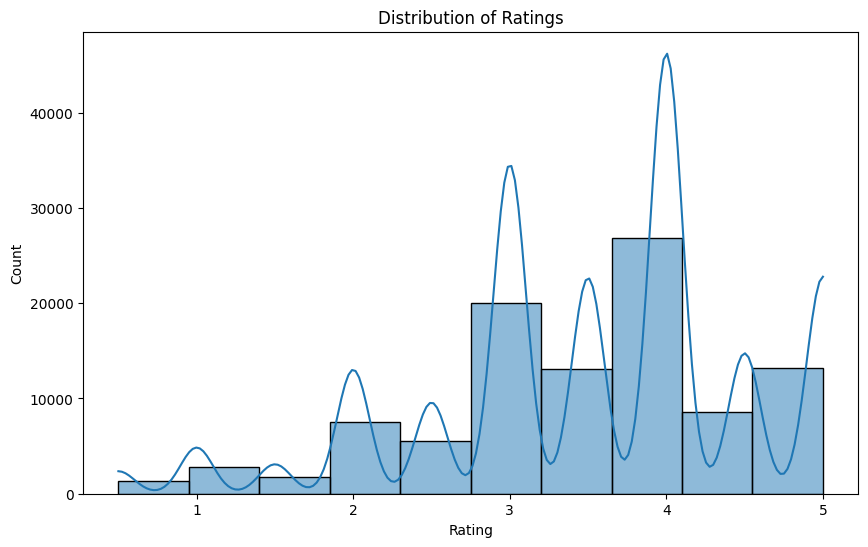

In [13]:
# Distribution of ratings
plt.figure(figsize=(10, 6))
sns.histplot(ratings_df['rating'], bins=10, kde=True)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

In [14]:
# Data Cleaning Functions
def clean_movie_data(movie_df):
    """Clean and prepare movie data"""
    # Handle any missing titles
    movie_df = movie_df.filter(col("title").isNotNull())
    
    # Extract year from title and create a new column
    movie_df = movie_df.withColumn(
        "year", 
        col("title").substr(-5, 4).cast("int")
    )
    
    # Extract genres into an array
    movie_df = movie_df.withColumn(
        "genres_array", 
        split(col("genres"), "\\|")
    )
    
    return movie_df

def clean_rating_data(rating_df):
    """Clean and prepare rating data"""
    # Remove any potential duplicates
    rating_df = rating_df.dropDuplicates(["userId", "movieId"])
    
    # Filter out any potential outlier ratings
    rating_df = rating_df.filter((col("rating") >= 0.5) & (col("rating") <= 5.0))
    
    return rating_df

# Apply cleaning functions
cleaned_movies = clean_movie_data(spark_movies)
cleaned_ratings = clean_rating_data(spark_ratings)

# Join datasets to get complete information
movie_ratings = cleaned_ratings.join(
    cleaned_movies, 
    on="movieId", 
    how="inner"
)

# Cache the dataframe for better performance
movie_ratings.cache()

# Show the joined data
print("Sample of joined movie ratings data:")
movie_ratings.show(5)

# Save processed data for later use
movie_ratings.write.mode("overwrite").parquet("processed_movie_data")

Sample of joined movie ratings data:


+-------+------+------+----------+--------------+------+----+------------+
|movieId|userId|rating| timestamp|         title|genres|year|genres_array|
+-------+------+------+----------+--------------+------+----+------------+
|     26|   599|   2.5|1498518655|Othello (1995)| Drama|1995|     [Drama]|
|     26|   483|   4.0|1215898801|Othello (1995)| Drama|1995|     [Drama]|
|     26|   474|   3.5|1136942664|Othello (1995)| Drama|1995|     [Drama]|
|     26|   470|   3.0| 849843245|Othello (1995)| Drama|1995|     [Drama]|
|     26|   182|   4.0|1063648819|Othello (1995)| Drama|1995|     [Drama]|
+-------+------+------+----------+--------------+------+----+------------+
only showing top 5 rows



In [15]:
# Feature Engineering for Content-Based Filtering

# 1. One-hot encode genres
from pyspark.ml.feature import CountVectorizer

# Explode the genres array to get one row per genre per movie
exploded_genres = cleaned_movies.select(
    "movieId", "title", "year", 
    explode(col("genres_array")).alias("genre")
)

# Create a pivot table to get genres as columns
genre_pivot = exploded_genres.groupBy("movieId").pivot("genre").count().fillna(0)

# Join back with movies
movies_with_features = cleaned_movies.join(genre_pivot, on="movieId", how="left")

# 2. Create user profile vectors based on their ratings
# Calculate average rating per user
user_avg_ratings = cleaned_ratings.groupBy("userId").avg("rating").withColumnRenamed("avg(rating)", "avg_rating")

# Calculate number of ratings per user
user_rating_count = cleaned_ratings.groupBy("userId").count().withColumnRenamed("count", "rating_count")

# Join to create user profiles
user_profiles = user_avg_ratings.join(user_rating_count, on="userId")

# Find genre preferences for each user
user_genre_prefs = movie_ratings.join(exploded_genres, on=["movieId"], how="inner") \
    .groupBy("userId", "genre") \
    .avg("rating") \
    .withColumnRenamed("avg(rating)", "genre_avg_rating")

# Pivot to get one column per genre
user_genre_matrix = user_genre_prefs.groupBy("userId").pivot("genre").avg("genre_avg_rating").fillna(0)

# Join with user profiles
complete_user_profiles = user_profiles.join(user_genre_matrix, on="userId", how="left")

# Display results
print("Sample Movie Features:")
movies_with_features.show(5)

print("Sample User Profiles:")
complete_user_profiles.show(5)

# Save engineered features
movies_with_features.write.mode("overwrite").parquet("movie_features")
complete_user_profiles.write.mode("overwrite").parquet("user_profiles")

Sample Movie Features:


Exception ignored in: <_io.BufferedWriter name=5>
Traceback (most recent call last):
  File "/Users/tushar/Documents/Startups/bdi-project/movie_rec_env/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 193, in manager
BrokenPipeError: [Errno 32] Broken pipe
Exception ignored in: <_io.BufferedWriter name=5>
Traceback (most recent call last):
  File "/Users/tushar/Documents/Startups/bdi-project/movie_rec_env/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 193, in manager
BrokenPipeError: [Errno 32] Broken pipe


+-------+--------------------+--------------------+----+--------------------+------------------+------+---------+---------+--------+------+-----+-----------+-----+-------+---------+------+----+-------+-------+-------+------+--------+---+-------+
|movieId|               title|              genres|year|        genres_array|(no genres listed)|Action|Adventure|Animation|Children|Comedy|Crime|Documentary|Drama|Fantasy|Film-Noir|Horror|IMAX|Musical|Mystery|Romance|Sci-Fi|Thriller|War|Western|
+-------+--------------------+--------------------+----+--------------------+------------------+------+---------+---------+--------+------+-----+-----------+-----+-------+---------+------+----+-------+-------+-------+------+--------+---+-------+
|      6|         Heat (1995)|Action|Crime|Thri...|1995|[Action, Crime, T...|                 0|     1|        0|        0|       0|     0|    1|          0|    0|      0|        0|     0|   0|      0|      0|      0|     0|       1|  0|      0|
|      5|Father 

+------+------------------+------------+------------------+-----------------+------------------+-----------------+------------------+------------------+------------------+-----------------+-----------------+-----------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+------------------+
|userId|        avg_rating|rating_count|(no genres listed)|           Action|         Adventure|        Animation|          Children|            Comedy|             Crime|      Documentary|            Drama|          Fantasy|         Film-Noir|            Horror|              IMAX|           Musical|           Mystery|           Romance|            Sci-Fi|          Thriller|               War|           Western|
+------+------------------+------------+------------------+-----------------+------------------+-----------------+------------------+------------------+----------------

In [16]:
# Feature Engineering for Content-Based Filtering

# 1. One-hot encode genres
from pyspark.ml.feature import CountVectorizer

# Explode the genres array to get one row per genre per movie
exploded_genres = cleaned_movies.select(
    "movieId", "title", "year", 
    explode(col("genres_array")).alias("genre")
)

# Create a pivot table to get genres as columns
genre_pivot = exploded_genres.groupBy("movieId").pivot("genre").count().fillna(0)

# Join back with movies
movies_with_features = cleaned_movies.join(genre_pivot, on="movieId", how="left")

# 2. Create user profile vectors based on their ratings
# Calculate average rating per user
user_avg_ratings = cleaned_ratings.groupBy("userId").avg("rating").withColumnRenamed("avg(rating)", "avg_rating")

# Calculate number of ratings per user
user_rating_count = cleaned_ratings.groupBy("userId").count().withColumnRenamed("count", "rating_count")

# Join to create user profiles
user_profiles = user_avg_ratings.join(user_rating_count, on="userId")

# Find genre preferences for each user
user_genre_prefs = movie_ratings.join(exploded_genres, on=["movieId"], how="inner") \
    .groupBy("userId", "genre") \
    .avg("rating") \
    .withColumnRenamed("avg(rating)", "genre_avg_rating")

# Pivot to get one column per genre
user_genre_matrix = user_genre_prefs.groupBy("userId").pivot("genre").avg("genre_avg_rating").fillna(0)

# Join with user profiles
complete_user_profiles = user_profiles.join(user_genre_matrix, on="userId", how="left")

# Display results
print("Sample Movie Features:")
movies_with_features.show(5)

print("Sample User Profiles:")
complete_user_profiles.show(5)

# Save engineered features
movies_with_features.write.mode("overwrite").parquet("movie_features")
complete_user_profiles.write.mode("overwrite").parquet("user_profiles")

Sample Movie Features:


Exception ignored in: <_io.BufferedWriter name=5>
Traceback (most recent call last):
  File "/Users/tushar/Documents/Startups/bdi-project/movie_rec_env/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 193, in manager
BrokenPipeError: [Errno 32] Broken pipe
Exception ignored in: <_io.BufferedWriter name=5>
Traceback (most recent call last):
  File "/Users/tushar/Documents/Startups/bdi-project/movie_rec_env/lib/python3.13/site-packages/pyspark/python/lib/pyspark.zip/pyspark/daemon.py", line 193, in manager
BrokenPipeError: [Errno 32] Broken pipe


+-------+--------------------+--------------------+----+--------------------+------------------+------+---------+---------+--------+------+-----+-----------+-----+-------+---------+------+----+-------+-------+-------+------+--------+---+-------+
|movieId|               title|              genres|year|        genres_array|(no genres listed)|Action|Adventure|Animation|Children|Comedy|Crime|Documentary|Drama|Fantasy|Film-Noir|Horror|IMAX|Musical|Mystery|Romance|Sci-Fi|Thriller|War|Western|
+-------+--------------------+--------------------+----+--------------------+------------------+------+---------+---------+--------+------+-----+-----------+-----+-------+---------+------+----+-------+-------+-------+------+--------+---+-------+
|      6|         Heat (1995)|Action|Crime|Thri...|1995|[Action, Crime, T...|                 0|     1|        0|        0|       0|     0|    1|          0|    0|      0|        0|     0|   0|      0|      0|      0|     0|       1|  0|      0|
|      5|Father 

In [17]:
# Create train/test split for model evaluation
from pyspark.sql.functions import rand

# Split the ratings data: 80% training, 20% testing
train_df, test_df = cleaned_ratings.randomSplit([0.8, 0.2], seed=42)

# Cache datasets
train_df.cache()
test_df.cache()

print(f"Training set size: {train_df.count()}")
print(f"Test set size: {test_df.count()}")

# Save train/test sets
train_df.write.mode("overwrite").parquet("train_data")
test_df.write.mode("overwrite").parquet("test_data")

print("Data pipeline complete! Ready for model implementation.")

Training set size: 80704
Test set size: 20132


Data pipeline complete! Ready for model implementation.


25/04/17 01:02:57 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 976130 ms exceeds timeout 120000 ms
25/04/17 01:02:57 WARN SparkContext: Killing executors is not supported by current scheduler.
25/04/17 01:02:58 ERROR Inbox: Ignoring error
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRefByURI(RpcEnv.scala:102)
	at org.apache.spark.rpc.RpcEnv.setupEndpointRef(RpcEnv.scala:110)
	at org.apache.spark.util.RpcUtils$.makeDriverRef(RpcUtils.scala:36)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.driverEndpoint$lzycompute(BlockManagerMasterEndpoint.scala:124)
	at org.apache.spark.storage.BlockManagerMasterEndpoint.org$apache$spark$storage$BlockManagerMasterEndpoint$$